In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.integrate as integrate

from numpy import pi, exp, cos, sin, sqrt, cosh, log, tanh, arcsinh
import tinyarray as ta

from scipy.special import j0,k0
import time

In [2]:
import os
import pickle

In [3]:
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/Zenodo


In [4]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [5]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [6]:
def Fermi_function(E,T):
    '''returns the Fermi function at energy E and temperature T
    '''
    exp_beta_E = exp(E/T)
    
    if np.isposinf(exp_beta_E):
        return 0.
    elif np.isneginf(exp_beta_E):
        return 1.
    else: 
        return 1./(1. + exp_beta_E)


## Stochastic algorithm

In [7]:
def self_consistency_solver_stochastic(mz0, mu0, T, C, integral, niter=1000, stepsize=1.0,
                                nonzero=1e-2, zero_tol=1e-5, ftol=1e-8):
    ''' Solves the ferromagnetic mean-field equations self-consistently.
        A stochastic algorithm (Basin-hopping) is used to find the optimal mz and mu.
        It tries to find solutions with nonzero mz, if they exist.
           
        Parameters: mz0: float
                        initial guess for magnetization
                    mu0: float
                        initial guess for chemical potential
                    T: float
                        positive temperature
                    C: float
                        density (0 < C < 2)
                    integral: float
                        system-specific integral that should be obtained beforehand
                    
                        
        returns: mz, mu: floats
                    final solutions for magnetization and chemical potential
                 F: float
                    F(mz,mu) at the minimum
                            
    '''
    
    from scipy.optimize import basinhopping
    from numpy.linalg import norm
    
    # reformulate self-consistency equations as a root-finding problem of 
    # functions f1 and f2, i.e., for the optimal (mz,mu) we have that
    # f1(mz,mu) = f2(mz,mu) = 0
    
    def f1(mz, mu):
        return mz  + integral/2 * (Fermi_function(mz-mu, T) - Fermi_function(-mz-mu, T))

    def f2(mz, mu):
        return C - (Fermi_function(mz-mu, T) + Fermi_function(-mz-mu, T))
    
    # the root-finding problem is reformulated as a minimization problem
    # of the function F(mz,mu) = f1(mz,mu)**2 + f2(mz,mu)**2
    
    def F(x):
        mz, mu = x
        return f1(mz,mu)**2 + f2(mz,mu)**2
    
    # We are interested in possible nonzero solutions for mz
    # However, mz=0 is always a solution of the self-consistency equation
    # Therefore, we keep track of minima outside the interval [-nonzero, nonzero]
    # and keep the stochastic algorithm from converging to mz=0 by only accepting 
    # solutions outside the interval [-zero_tol,zero_tol]
    
    nonzero_min = [F([mz0,mu0]), mz0, mu0]
    
    def accept_test(f_new, x_new, f_old, x_old):
        mz1, mu1 = x_new
        if abs(mz1) < zero_tol: 
            return False
        else:
            return True
    
    def callback(x, f, accept):        
        mz, mu = x
        fmin = nonzero_min[0]
        if f < fmin and abs(mz) > nonzero:
            nonzero_min[0] = f
            nonzero_min[1] = mz
            nonzero_min[2] = mu
               
    x0 = [mz0, mu0]
    results = basinhopping(F, x0, stepsize=stepsize, niter=niter, 
                           accept_test=accept_test, callback=callback)

    # If there exists a minimum (<ftol) away from mz=0, return that one.
    # Otherwise, return the minimum with mz=0.
           
    if nonzero_min[0] < ftol:
        return nonzero_min[1], nonzero_min[2], nonzero_min[0] # mz, mu, F(mz,mu)
    else:
        return results['x'][0], results['x'][0], results['fun'] # mz, mu, F(mz,mu)

In [8]:
def initiate(C):
    ''' Initiates (mz,mu) with random values from a small neighborhood around the expected
        values for the given C at T=0
    '''
    sign = np.sign(np.random.random_sample()-0.5)
    if C<1:
        mz0 = sign*(0.5*C*(1 + 0.1*(2*np.random.random_sample()-1))) 
        mu0 = -0.5*C*(1 + 0.1*(2*np.random.random_sample()-1))
    elif C==1:
        mz0 = sign*(0.5 + 0.05*(2*np.random.random_sample()-1)) 
        mu0 = 0. + 0.05*(2*np.random.random_sample()-1)
    if C>1:
        mz0 = sign*(0.5*(2-C)*(1 + 0.1*(2*np.random.random_sample()-1))) 
        mu0 = 0.5*(C-1)*(1 + 0.1*(2*np.random.random_sample()-1))
    return mz0, mu0

In [ ]:
import warnings
warnings.filterwarnings('ignore')

integral=1.0

nT = 51
nC = 51
Ts = np.linspace(0.001, 0.3, nT)
Cs = np.linspace(0., 2., nC)

mzs = np.zeros((nC,nT))
mus = np.zeros((nC,nT))
errs= np.zeros((nC,nT))

counter = 1
for i,C in enumerate(Cs):
    mz0, mu0 = initiate(C)
    for j,T in enumerate(Ts):
        print('\rcomputing phase diagram... {} of {}'.format(counter, nT*nC), end='')
        results = self_consistency_solver_stochastic(mz0, mu0, T, C, integral)
        mzs[i,j] = results[0]
        mus[i,j] = results[1]
        errs[i,j] = results[2]
        mz0 = mzs[i,j]
        mu0 = mus[i,j]
        counter += 1
        #print(i, j, results)

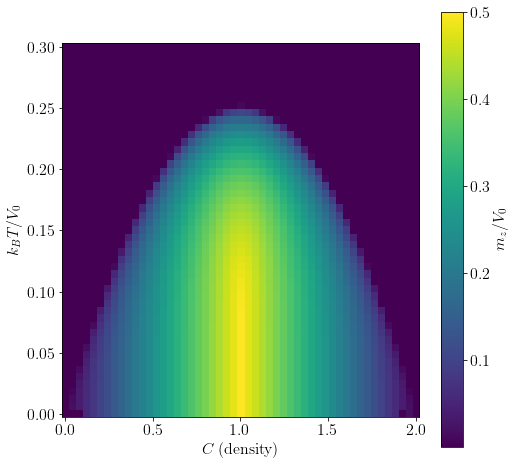

In [65]:
plt.figure(figsize=(8,8))
dT = (Ts[1]-Ts[0])/2
dC = (Cs[1]-Cs[0])/2
plt.imshow(abs(mzs).transpose(), extent=(Cs[0]-dC,Cs[-1]+dC,Ts[0]-dT,Ts[-1]+dT), 
           aspect=7, origin='lower', interpolation='nearest')
#plt.plot(Cs, 0.25*Cs*(2.-Cs), c='red')
plt.xlabel('$C\:\mathrm{(density)}$')
plt.ylabel('$k_BT/V_0$')
plt.colorbar(label='$m_z/V_0$')

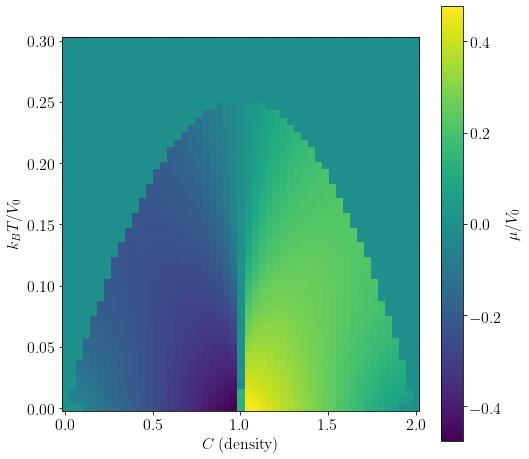

In [64]:
plt.figure(figsize=(8,8))
dT = (Ts[1]-Ts[0])/2
dC = (Cs[1]-Cs[0])/2
plt.imshow(mus.transpose(), extent=(Cs[0]-dC,Cs[-1]+dC,Ts[0]-dT,Ts[-1]+dT), 
           aspect=7, origin='lower', interpolation='nearest')
#plt.plot(Cs, 0.25*Cs*(2.-Cs), c='red')
plt.xlabel('$C\:\mathrm{(density)}$')
plt.ylabel('$k_BT/V_0$')
plt.colorbar(label='$\mu/V_0$')

In [66]:
params = dict(integral=integral)

In [67]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'ferromagnetic_meanfield_C_T'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(Cs, fp)
pickle.dump(Ts, fp)
pickle.dump(mzs, fp)
pickle.dump(mus, fp)
pickle.dump(errs, fp)
#fp.close()

## $V_0$ as a function of $R$

In [10]:
def momentum_sum(t1, t2, R, rmax=20., limit=1000):
    ''' Computes the momentum sum in the mean-field equations in units of the Coulomb factor V_C.
        V_C is defined in terms of l0: 
        
        V_C = 1/(4*pi*eps*eps0) * 1/l0
    
        R: curvature radius (in l0)
        t1, t2: model parameters (in units of t)
        rmax: upper bound for the r integration (in l0)
        limit: maximum number of iterations for the numerical integration (quad)    
    '''
    
    Q = sqrt(t1)*t2*R
    lD = sqrt(Q/R)/t2
    
    qmin = -np.inf
    qmax = +np.inf
    
    rmin = 0.
    
    def func_q(r):
        return (integrate.quad(lambda q: exp(-lD**4 * q**2 /2) * j0((Q+q)*r), qmin, qmax,limit=limit))[0]
    
    def func_r(r):
        if r <= 20.:
            return r * func_q(r) * exp(r**2/4) * k0(r**2/4) * j0(Q*r)
        else:
            # replace exp(r**2/4)*k0(r**2/4) by leading order term of asymptotic series ~1/r
            return func_q(r) * sqrt(2*pi) * j0(Q*r)
    
    integral, err = integrate.quad(func_r, rmin, rmax, limit=limit)
    
    return sqrt(1./(2*pi))*Q*integral, err

In [12]:
def compute_l0(t, t2, d, R):
    '''Computes l0 in units of Angstrom (0.1 nm)
       
       t, t2: hopping parameters in eV
       d: lattice constant in Angstrom
       R: curvature radius in Angstrom     
    '''
    return sqrt(t2*d*R/t)

In [92]:
# system parameters in conventional units
d = 9.7 # in Angstrom
t = 0.21 # in eV
t1 = 0.25*t
t2 = 0.8*t

In [142]:
Rs = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.2, 1.4, 1.6, 1.8,
      2, 2.4, 2.8, 3.2, 3.6, 4, 4.4, 4.8, 5.2, 5.6, 6,
      6.4, 6.8, 7.2, 7.6, 8, 9, 10, 15, 20, 30, 40, 
      60, 80, 100] # in microns
V0s = []
print(len(Rs))

35


In [198]:
n_rmax = 11
rmax0 = 0.05 
rmax1 = 4.0

rmaxs = np.linspace(rmax0, rmax1, n_rmax)
momentum_sums = np.zeros(n_rmax)
sum_errs = np.zeros(n_rmax)

In [392]:
l0 = compute_l0(t, t2, d, Rs[j]*1e4) 
# R must be in Angstrom
print(l0) # in Angstrom

2785.677655436824


In [393]:
for i,rmax in tqdm(list(enumerate(rmaxs))):
    momentum_sums[i], sum_errs[i] = momentum_sum(t1/t, t2/t, Rs[j]*1e4/l0, rmax)
    # R must be in Angstrom to be compatible with l0

lim I/VC = 1.5637323291751732


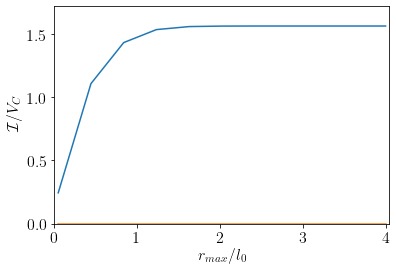

In [394]:
plt.plot(rmaxs, momentum_sums)
plt.plot(rmaxs, sum_errs)
plt.xlabel('$r_{max}/l_0$')
plt.ylabel('$\mathcal{I}/V_C$')
plt.xlim(0,rmaxs[-1]*1.01)
plt.ylim(0,max(momentum_sums)*1.1)
integral = momentum_sums[-1]
print('lim I/VC =', momentum_sums[-1])

In [395]:
# This integral V0 is in units of VC with l0 as length scale.
# To convert this to units of VC with d as length scale, we have to apply the following transformation:
# V0/VC_d = integral * d\l0

In [396]:
V0s.append(integral*d/l0)
print(integral*d/l0)

0.005445067760584324


Text(0, 0.5, '$V_0/V_{C,d}$')

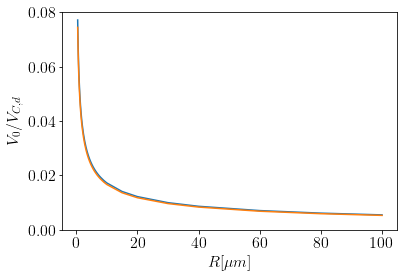

In [440]:
plt.plot(Rs[0:len(V0s)],V0s)
plt.plot(Rs,1/sqrt(Rs)/19)
plt.ylim(0,0.08)
plt.xlabel('$R[\mu m]$')
plt.ylabel('$V_0/V_{C,d}$')

In [441]:
# T_c
kB = 8.617333262145e-5 # in eV/K
epsilon = 100
Tcs = 0.25*np.array(V0s)* 14.3996/d/epsilon /kB

Text(0, 0.5, '$T_c[K]$')

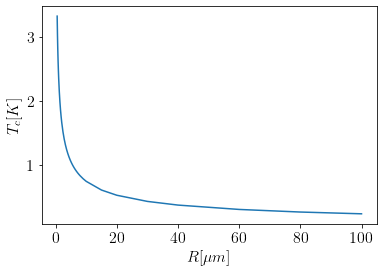

In [442]:
plt.plot(Rs[0:len(V0s)],Tcs)
#plt.ylim(0,0.08)
plt.xlabel('$R[\mu m]$')
plt.ylabel('$T_c[K]$')

#### Save to file for figures

In [401]:
params = dict(t=t, t1=t1, t2=t2, d=d)

In [402]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'magnetic_V0_scaling'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(Rs, fp)
pickle.dump(V0s, fp)
#fp.close()